In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt


In [11]:
!pip install imbalanced-learn



In [12]:
cols = ["fLength", "fWidth", "fSize", "fCone", "fCone1", "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist", "class"]
df = pd.read_csv("magic04.data", names=cols)
df.head()


,fLength,fWidth,fSize,fCone,fCone1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


In [13]:
df["class"] = (df["class"] == "g").astype(int)

In [14]:
df.head()

,fLength,fWidth,fSize,fCone,fCone1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


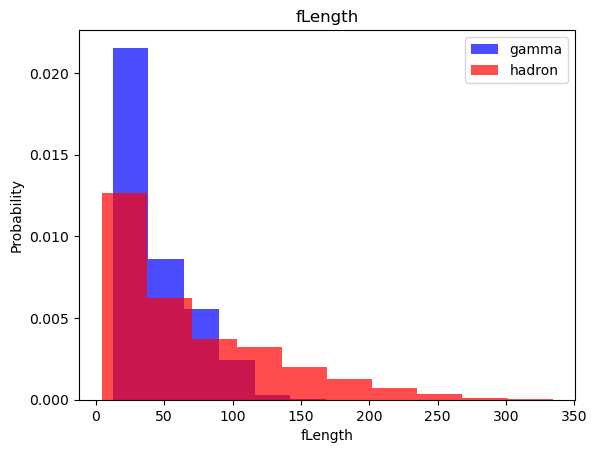

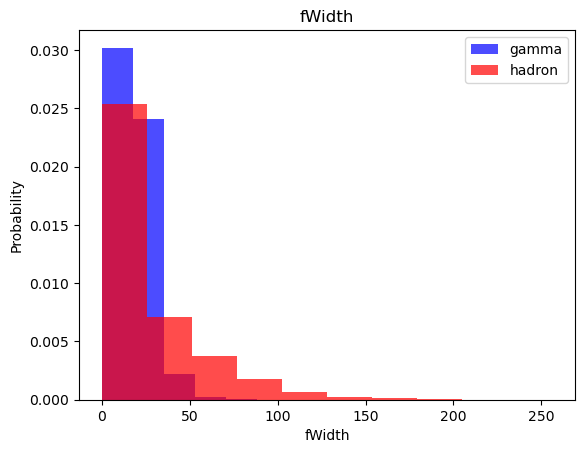

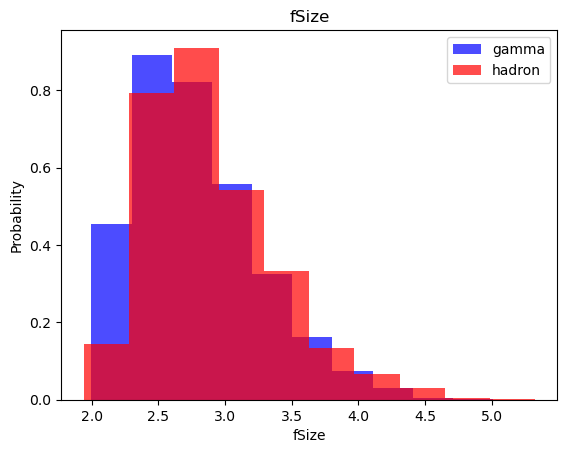

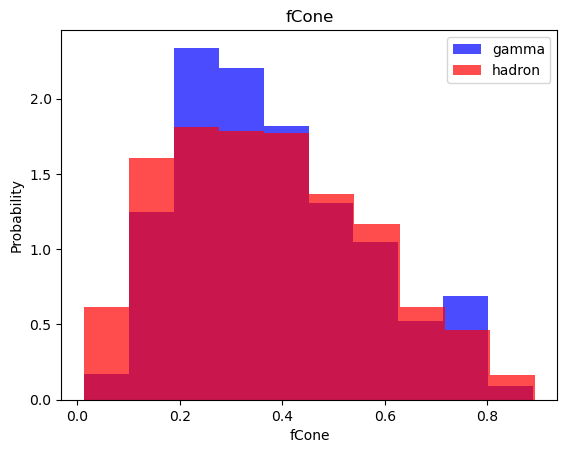

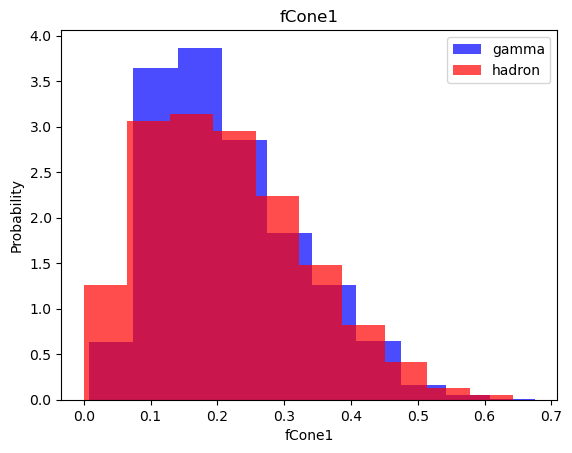

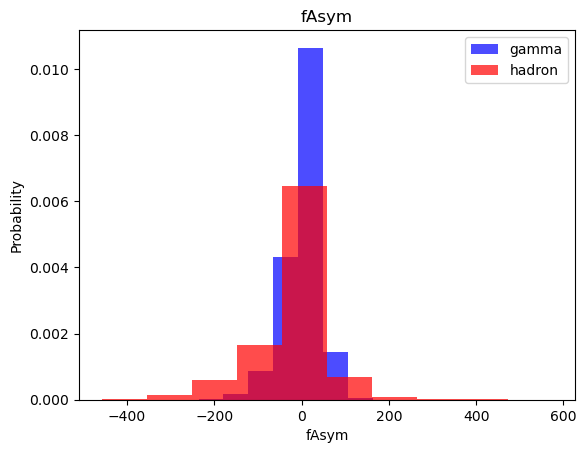

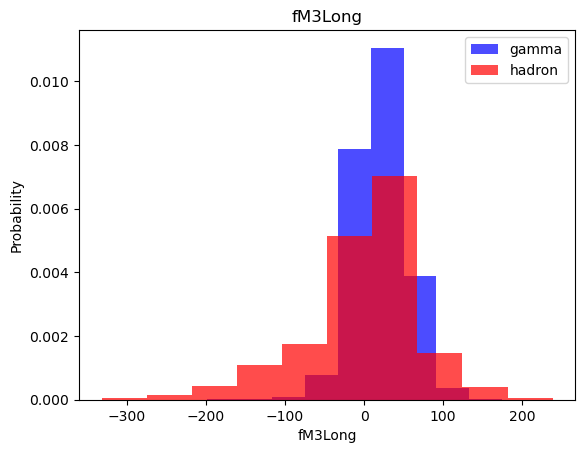

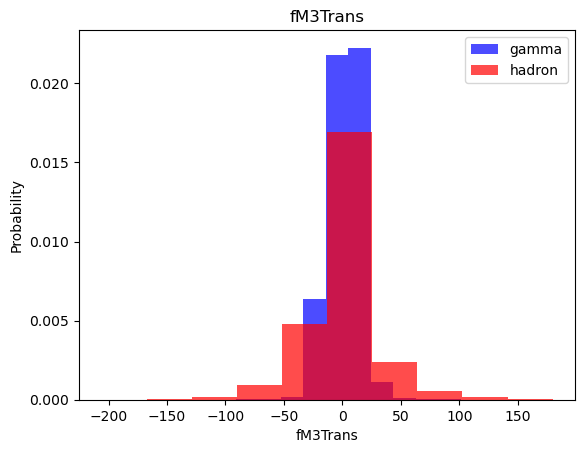

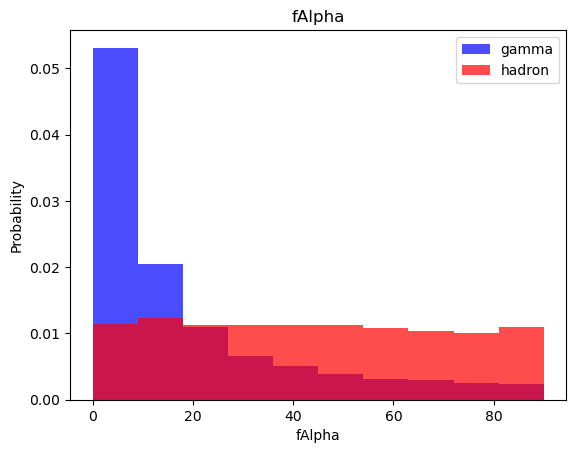

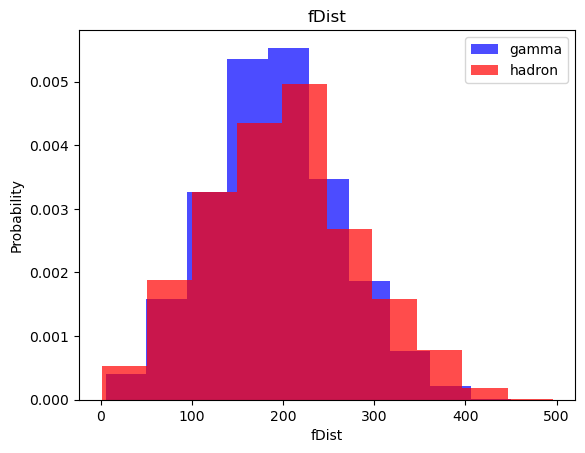

In [15]:
for label in cols[:-1]:
    plt.hist(df[df["class"]==1][label], color="blue", label="gamma", alpha=0.7, density=True)
    plt.hist(df[df["class"]==0][label], color="red", label="hadron", alpha=0.7, density=True)
    plt.title(label)
    plt.ylabel("Probability")
    plt.xlabel(label)
    plt.legend()
    plt.show()
    

In [16]:
#Train, validation, test datasets
train, valid, test = np.split(df.sample(frac=1), [int(0.6*len(df)), int(0.8*len(df))])


C:\Users\spiro\miniconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [17]:
def scale_dataset(dataframe, oversample=False):
    X = dataframe.iloc[:, :-1].values
    y = dataframe.iloc[:, -1].values


    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    if oversample:
        ros = RandomOverSampler()
        X, y = ros.fit_resample(X, y)

    data = np.hstack((X, np.reshape(y, (-1, 1))))

    return data, X,y
    

In [18]:
print (len(train[train["class"]==1])) #gamma
print (len(train[train["class"]==0]))

7395
4017


In [19]:
train_data, X_train, y_train = scale_dataset(train, oversample=True)
valid_data, X_valid, y_valid = scale_dataset(valid, oversample=False)
test_data, X_test, y_test = scale_dataset(test, oversample=False)

In [20]:
len(y_train)

14790

In [21]:
sum(y_train == 1)

np.int64(7395)

In [22]:
sum(y_train == 0)

np.int64(7395)

In [23]:
#ΚΝΝ
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


In [24]:
knn_model = KNeighborsClassifier(n_neighbors = 5)
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [25]:
y_pred = knn_model.predict(X_test)

In [26]:
y_pred

array([1, 1, 1, ..., 0, 1, 1], shape=(3804,))

In [27]:
y_test

array([1, 1, 1, ..., 0, 1, 1], shape=(3804,))

In [28]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.74      0.74      1321
           1       0.86      0.86      0.86      2483

    accuracy                           0.82      3804
   macro avg       0.80      0.80      0.80      3804
weighted avg       0.82      0.82      0.82      3804



In [29]:
#Naive Bayes
from sklearn.naive_bayes import GaussianNB

In [30]:
nb_model = GaussianNB()
nb_model = nb_model.fit(X_train, y_train)

In [31]:
y_pred = nb_model.predict(X_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.40      0.50      1321
           1       0.74      0.90      0.81      2483

    accuracy                           0.72      3804
   macro avg       0.70      0.65      0.65      3804
weighted avg       0.71      0.72      0.70      3804



In [32]:
#Log Regression
from sklearn.linear_model import LogisticRegression

In [33]:
lg_model = LogisticRegression()
lg_model = lg_model.fit(X_train, y_train)

In [34]:
y_pred = lg_model.predict(X_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.71      0.69      1321
           1       0.84      0.82      0.83      2483

    accuracy                           0.78      3804
   macro avg       0.76      0.76      0.76      3804
weighted avg       0.78      0.78      0.78      3804



In [35]:
#SVM
from sklearn.svm import SVC

In [36]:
svm_model = SVC()
svm_model = svm_model.fit(X_train, y_train)

In [37]:
y_pred = svm_model.predict(X_test)
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.80      0.80      1321
           1       0.89      0.89      0.89      2483

    accuracy                           0.86      3804
   macro avg       0.84      0.84      0.84      3804
weighted avg       0.86      0.86      0.86      3804



In [38]:
!pip install tensorflow


In [39]:
#Neural Net
import tensorflow as tf


In [46]:
def train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs):
    # Δημιουργία του μοντέλου (με 4 κενά στοίχιση)
    nn_model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(10,)),
        
        tf.keras.layers.Dense(num_nodes, activation="relu"),
        tf.keras.layers.Dropout(dropout_prob),
        
        tf.keras.layers.Dense(num_nodes, activation="relu"),
        tf.keras.layers.Dropout(dropout_prob),
        
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    # Compile του μοντέλου (κλείνει σωστά η παρένθεση στο τέλος)
    nn_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr), 
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    # Διορθώθηκε το nn_model, το y_train και το batch_size
    history = nn_model.fit(
        X_train, y_train, 
        epochs=epochs, 
        batch_size=batch_size, 
        validation_split=0.2, 
        verbose=0
    )

    return nn_model, history

                 

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


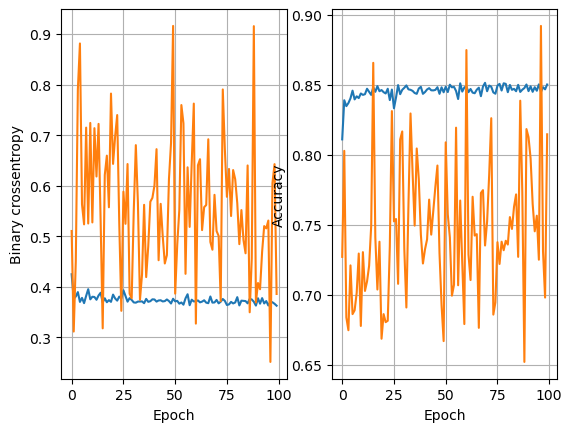

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


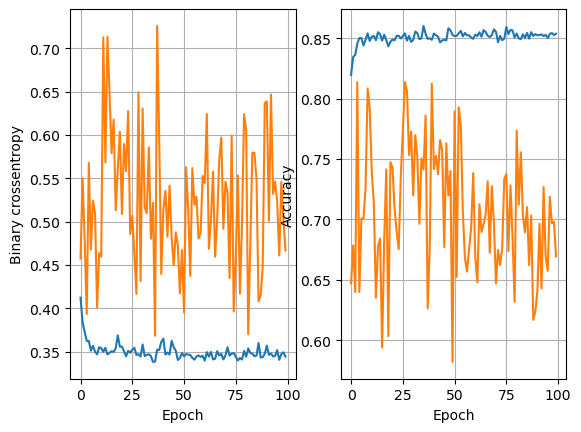

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


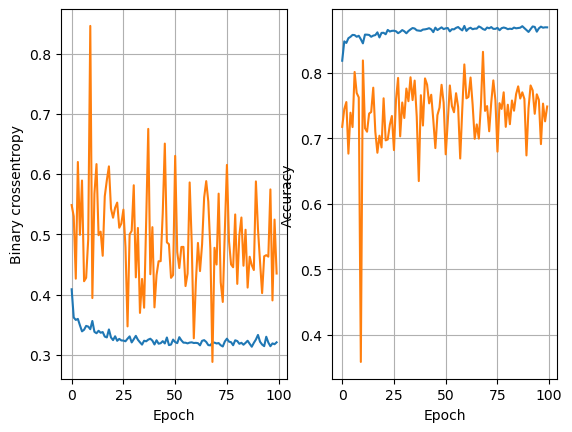

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


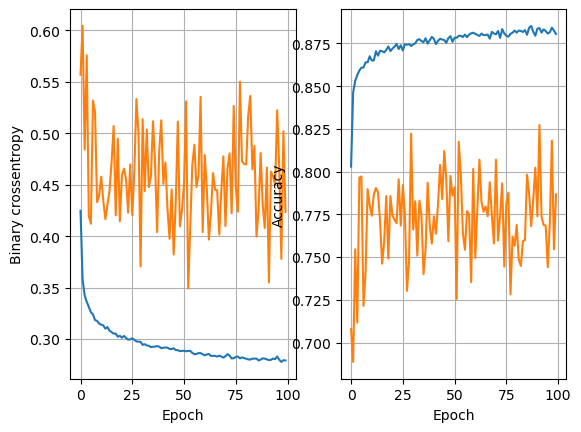

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


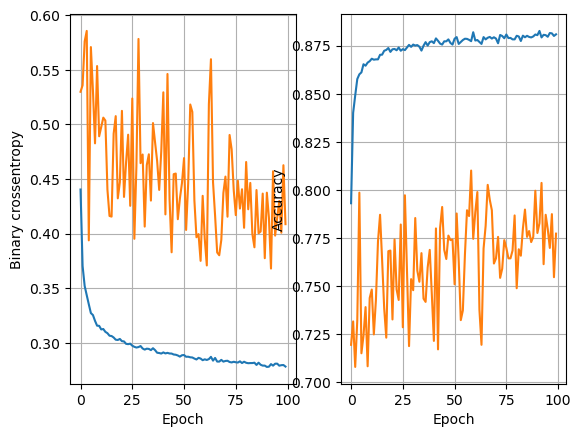

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


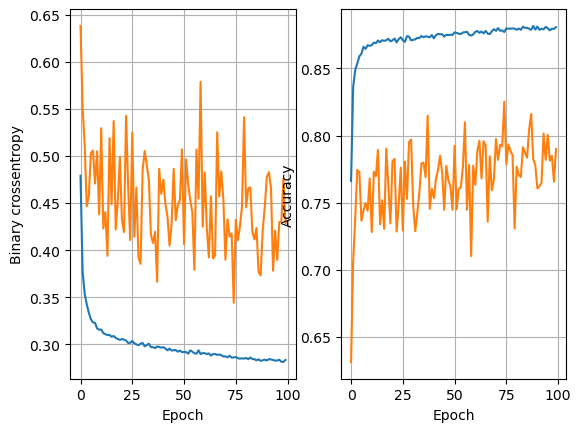

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


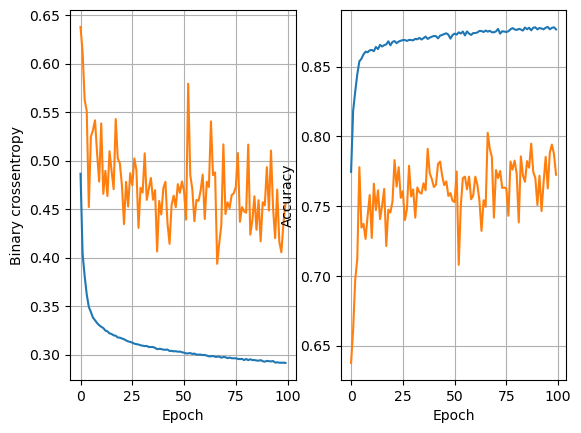

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


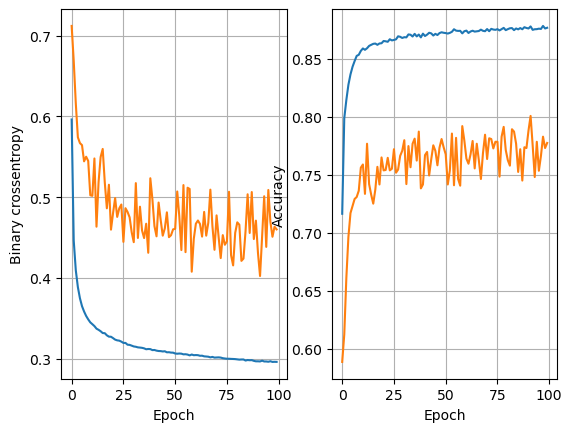

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


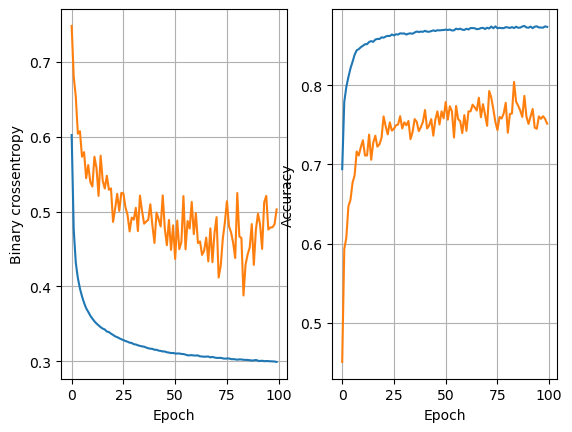

(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)


KeyboardInterrupt: 

In [54]:
least_val_loss = float("inf")
least_loss_model = None
epochs = 100
for num_nodes in [16, 32, 64]:
    for dropout_prob in [0, 0.2]:
        for lr in  [0.1, 0.005, 0.001]:
            for batch_size in [32, 64, 128]:
                print(f"(num_nodes) nodes, dropout, (dropout_prob), lr (lr), batch size (batch_size)")
                model, history = train_model(X_train, y_train, num_nodes, dropout_prob, lr, batch_size, epochs)
                plot_history(history)
                val_loss = model.evaluate(X_valid, y_valid, verbose=0)[0]
                if val_loss < least_val_loss:
                    least_val_loss = val_loss
                    least_loss_model = model

In [56]:
y_pred = least_loss_model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).reshape(-1,)


119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [57]:
print (classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1321
           1       0.88      0.94      0.91      2483

    accuracy                           0.87      3804
   macro avg       0.87      0.85      0.86      3804
weighted avg       0.87      0.87      0.87      3804



In [50]:
def plot_history(history):
    fig, (ax1, ax2)  = plt.subplots (1, 2)
    ax1.plot(history.history["loss"], label="loss")
    ax1.plot(history.history["val_loss"], label="val_loss") # Διορθώθηκε σε val_loss
    ax1.set_xlabel("Epoch") # Διορθώθηκε σε Epoch
    ax1.set_ylabel("Binary crossentropy")
    ax1.grid(True)

    ax2.plot(history.history["accuracy"], label="accuracy")
    ax2.plot(history.history["val_accuracy"], label="val_accuracy")
    ax2.set_xlabel("Epoch") # Διορθώθηκε σε Epoch
    ax2.set_ylabel("Accuracy")
    ax2.grid(True)
    
    plt.show()




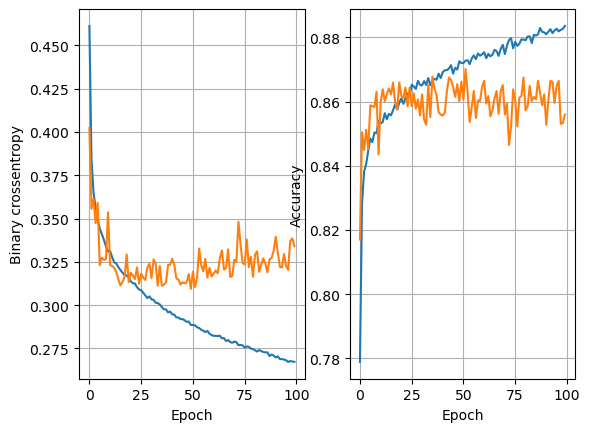

In [51]:
plot_history(history)

In [ ]:

history = nn_model.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=32, 
    validation_data=(X_valid, y_valid)
)   


Epoch 1/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7789 - loss: 0.4613 - val_accuracy: 0.8170 - val_loss: 0.4023
Epoch 2/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8281 - loss: 0.3841 - val_accuracy: 0.8504 - val_loss: 0.3556
Epoch 3/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8382 - loss: 0.3651 - val_accuracy: 0.8449 - val_loss: 0.3615
Epoch 4/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8406 - loss: 0.3562 - val_accuracy: 0.8512 - val_loss: 0.3473
Epoch 5/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8447 - loss: 0.3495 - val_accuracy: 0.8452 - val_loss: 0.3591
Epoch 6/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8485 - loss: 0.3442 - val_accuracy: 0.8588 - val_loss: 0.3231
Epoch 7/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8474 - loss: 0.3411 - val_accuracy: 0.8586 - val_loss: 0.3274
Epoch 8/100
463/463 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8504 - loss: 0.3378 - val_accu

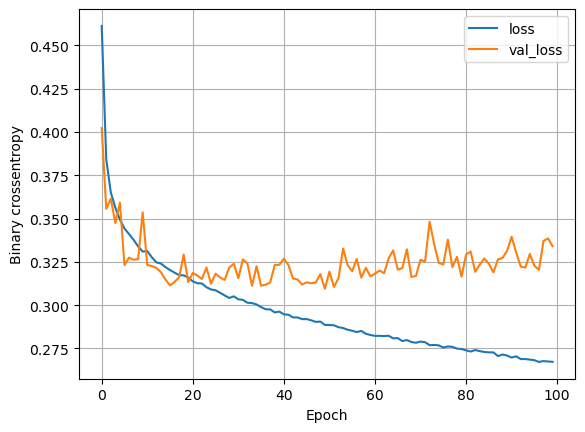

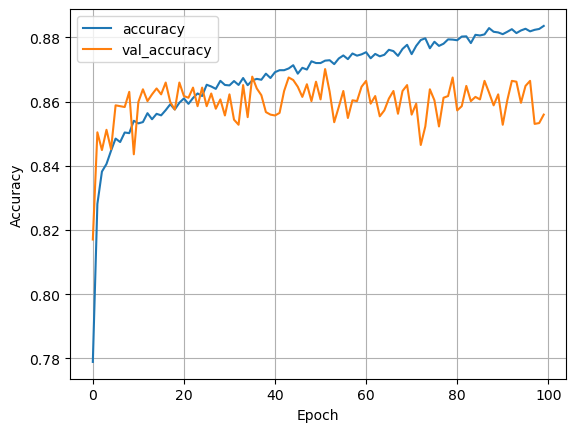

In [44]:
plot_loss(history)
plot_accuracy(history)